# Bayesian Modeling in RStan

This article is part of a series:

- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20I%20-%20Bayesian%20Inference.ipynb">Bayesian Inference I - Bayesian Inference</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20II%20-%20Bayesian%20Linear%20Regression.ipynb">Bayesian Inference II - Bayesian Linear Regression</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20III%20-%20Extending%20Bayesian%20Regression.ipynb">Bayesian Inference III - Extending Bayesian Regression</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20IV%20-%20Bayesian%20Networks%20Discrete.ipynb">Bayesian Inference IV - Discrete Bayesian Networks</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20V%20-%20Bayesian%20Networks%20Continuous%20and%20Hybrid.ipynb">Bayesian Inference V - Continuous and Hybrid Bayesian Networks</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20VI%20-%20BN%20Practical%20Applications.ipynb">Bayesian Inference VI - BN Practical Applications</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20VII%20-%20Bayesian%20Modeling%20in%20RStan.ipynb">Bayesian Inference VII - Bayesian Modeling in RStan</a>
- <i>more at <a href="https://pw598.github.io/">pw598.github.io</a></i>

But I will write it as a standalone, summarizing the previous articles at a high level.

# Outline

- Bayesian Data Analysis
- The Prior Distribution
- Choosing a Prior
- Software
- The Urinalysis Data
- Bayesian Networks
- Implementation
- Doing it With Priors
- Probabilistic Linear Modeling
- Putting it All Together

# Bayesian Data Analysis

Bayesian data analysis is a subset of statistical methods that utilize Bayes' theorem, which describes the probability of an event based on knowledge or conditions related to that event.

$P(A|B) = \frac{P(B|A)P(A)}{P(B)} = \frac{P(B|A)P(A)}{P(B|A)P(A) + P(B|A')P(A')}$

where | means 'given' and $A'$ means the complement of $A$, i.e., not $A$. Nothing is controversial about this formulation, as it is derived from the law of conditional probability,

$P(A \text{ and } B) = P(A|B)P(B) = P(B|A)P(A)$.

In the context of Bayesian data analysis, these variables often refer to probability distributions, and they take on additional terminology. $P(A|B)$ is the posterior distribution, comprised of $P(B|A)$, which is the likelihood, multiplied by $P(A)$, which is the prior, and divided by $P(B)$, the marginal likelihood. Where Bayesian statistics can get controversial is in the dependence on the use of the prior, which as the name suggests, is often an expression of prior belief. This can be a hunch, information from external sources, information from a prior experiment, etc. More on priors in a bit.

When searching for the parameters $\theta$ of distribution functions $f()$, we write:

$f(\theta|y) = \frac{f(y|\theta)f(\theta)}{f(y)} = \frac{f(y|\theta)f(\theta)}{\int f(y|\theta) f(\theta) ~d \theta}$

We use an integral in the denominator rather than a sum because distributions can be continuous. A challenge is that, depending on the distributions chosen, this denominator can be analytically intractable. Options for dealing with this include:
1. Ignoring the denominator and focusing of proportionality of the numerator to the posterior distribution.

2. Using conjugate priors, special pairings of prior distribution and likelihood distribution whereby the prior and posterior end up being of the same family (these are analytically calculable, and quick to compute).

3. Using approximation methods such as Markov Chain Monte Carlo (MCMC), which continue to increase in capability and popularity because of the lack of constraint.

We will focus on approximation sampling through <code>rstan</code>, a package in R which utilizes the C++ sampler <code>stan</code>, but not get into the weeds of the sampler's underlying processes. While it is good for practitioners to be familiar with diagnostics, the sampler may have varied and complicated designs, and is usually treated as a black-box inference button.

# The Prior Distribution

The prior distribution has been rightfully accused of allowing researchers to sneak in extra degrees of freedom; so are we abandoning objectivity by injecting one? Sticking with the traditional connotations of objectivity and subjectivity (here is a <a href="http://www.stat.columbia.edu/~gelman/research/published/objectivityr5.pdf">paper</a> arguing the semantics), one could ask, are we truly being objective if not incorporating prior information when it would be meaningful to do so; i.e., when the information is robust, and the sample size at hand is small, or the data noisy? And if sample size is large enough that we're not worried, then should we not be seeking to answer finer-grained questions? (<a href="https://statmodeling.stat.columbia.edu/2005/07/31/n_is_never_larg/">Here</a> is a short blog post from Andrew Gelman on that subject).

This speaks toward something known as the reproducibility crisis. Particularly in sciences where an experiment's sample size tends to be small, researchers often have trouble replicating the work of the past, including that reflected in existing literature, and it's partly because of the way we do statistics.

-----
<i>"The frequentist approach requires that all probabilities be defined by connection to the frequencies of events in very large samples. This leads to frequentist uncertainty being premised on imaginary resampling of data."</i>
- Statistical Rethinking (2019)
-----

<i>"The sampling distribution is defined by the stopping and testing intuitions of the researcher. There, for any fixed set of data, different stopping or testing interactions yield different p-values and confidence intervals. Moreover, confidence intervals have no distributed information."</i>
- The Bayesian New Statistics (2017)
-----

Furthermore, we often treat variables as independent in frequentist analyses, whereas Bayesian analysis can account for conditional dependencies.

Another application illustrating the benefit of Bayesian analysis is sequential updating. Looking retrospectively at a time-series, it is easy to model a distribution, but had the inference been required as the data were trickling in, you would do well to assume a reasonable prior and continuously update that distribution, based on individual observations or groups of observations. The nature of this is such that the influence of the sequentially-updated likelihoods is the same as that of the pooled data retroactively.

Another popular method of incorporating Bayesian updating is with hierarchical modeling. For example, modeling the trend of a political poll at the state or province level to incorporate information about the aggregate, or modeling the times of individual runners over time to share an aggregate trend in terms of the impact of age.

One last example that I'll give of the benefit of Bayesian analysis is that when a classification problem is suffering from complete separation, meaning that the class 0 and class 1 items have no overlap over the predictor variable(s), placing a prior over a logistic regression will allow it to assume a curve instead of a step function, which is more realistic.

# Choosing a Prior

So how should we choose a prior? We can start by considering what kind of prior to use.

Flat priors attempt to reflect complete uncertainty, in an attempt to be 'objective' and let the data speak for itself. But for the reasons discussed above, this is about as disadvantageous as not using a prior at all. Weak priors attempt to provide very minimal information, and for quite some time, were preferred by leaders in the field. However, informative priors (where reasonable) or so-called 'weakly-informative' priors, have gained preference in recent years.

Empirical priors also attempt to be 'objective', by basing the prior upon the data. While many researchers agree that looking at the data (as opposed to 'pure Bayes') is acceptable and/or necessary, setting a prior purely based upon the data is generally seen as double-dipping upon the likelihood. An alternative (that sounds quite rational to me) is bootstrapping the data (resampling with replacement), fitting distributions to each sample empirically, and using the mean and variance of the parameters found while bootstrapping as the mean and variance of the priors.

There is obviously no one-size-fits-all default, but in terms of preferences toward getting the analysis started when there is little prior information to utilize, leading voice in the field <a href="http://www.stat.columbia.edu/~gelman/">Andrew Gelman</a> has expressed a preference for N(0,1) (upon standardized data), and fellow professor <a href="https://users.aalto.fi/~ave/">Aki Vehtari</a> (who with Andrew, was involved in creating <code>stan</code>) has expressed a fondness for t(3,0,1). I've sometimes found something like a t(10,0,1) to be a nice compromise between the two, after experimenting with both.

# Software

As mentioned above, Bayesian inference involves a generative model in which samples representing the posterior distribution are simulated, and then inferences are drawn from those samples. Andrew, Aki, and others developed the C++ package <code>stan</code>, which can be called upon from within R using <code>rstan</code>, or in Python using <code>pystan</code>. In Python, however, a module called <code>pymc</code> is more popular, and a module called <code>bambi</code> builds upon it to ease the construction of linear Bayesian models. We'll work with <code>rstan</code>.

Below, we import the libraries that will be used throughout.

In [ ]:
# install.packages("BiocManager")
# library("BiocManager")

# BiocManager::install("bnlearn")
# BiocManager::install("Rgraphviz")
# BiocManager::install("rstan")

# BiocManager::install("GGally")
# BiocManager::install("boot")

library(bnlearn)
library(Rgraphviz)
library(boot)
library(GGally)
library(rstan)
library(MASS)

# The Urinalysis Data

The data we'll use is from the R package <code>boot</code>, and describes the levels of various measures, with multiple conditional dependence relationships, in 79 urine samples. These variables include:

- <code>r</code>: indicator of the presence of calcium oxalate crystals.
- <code>gravity</code>: density dependent on dissolved particulates.
- <code>ph</code>: level of acidity or alkalinity
- <code>osmo</code>: osmolarity; proportional to the concentration of molecules in solution.
- <code>cond</code>: conductivity; proportional to the concentration of charged ions in solution.
- <code>urea</code>: urea concentration in millimoles per litre.
- <code>calc</code>: calcium concentration in millimoles per litre.

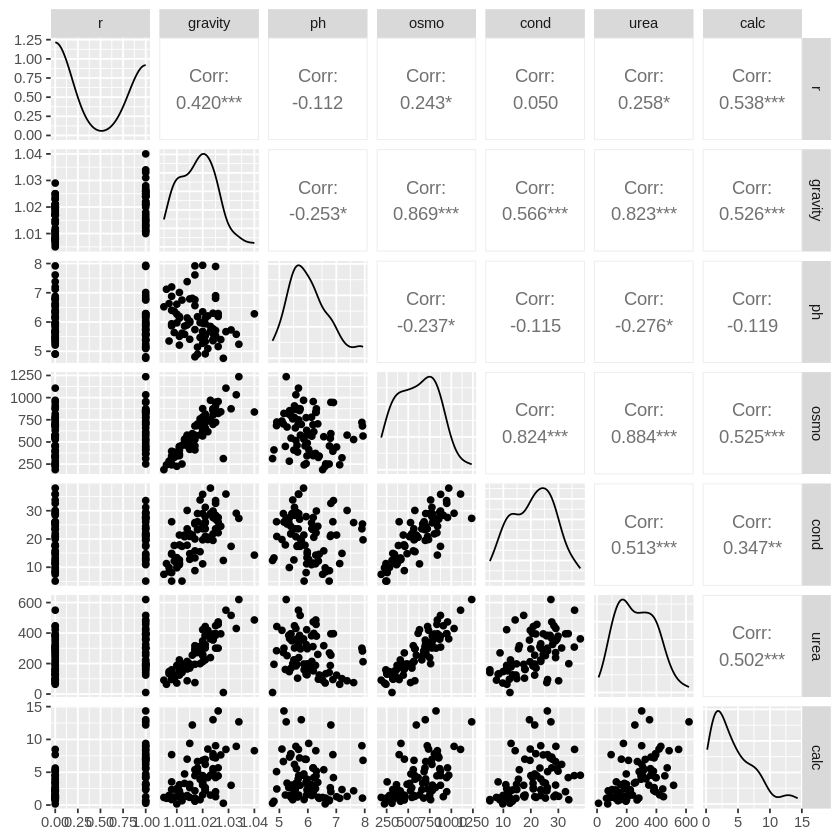

In [2]:
data <- urine

# impute a couple of missing values
data$osmo[is.na(data$osmo)] <- mean(data$osmo, na.rm = TRUE)
data$cond[is.na(data$cond)] <- mean(data$cond, na.rm = TRUE)

# pair plot
ggpairs(data)

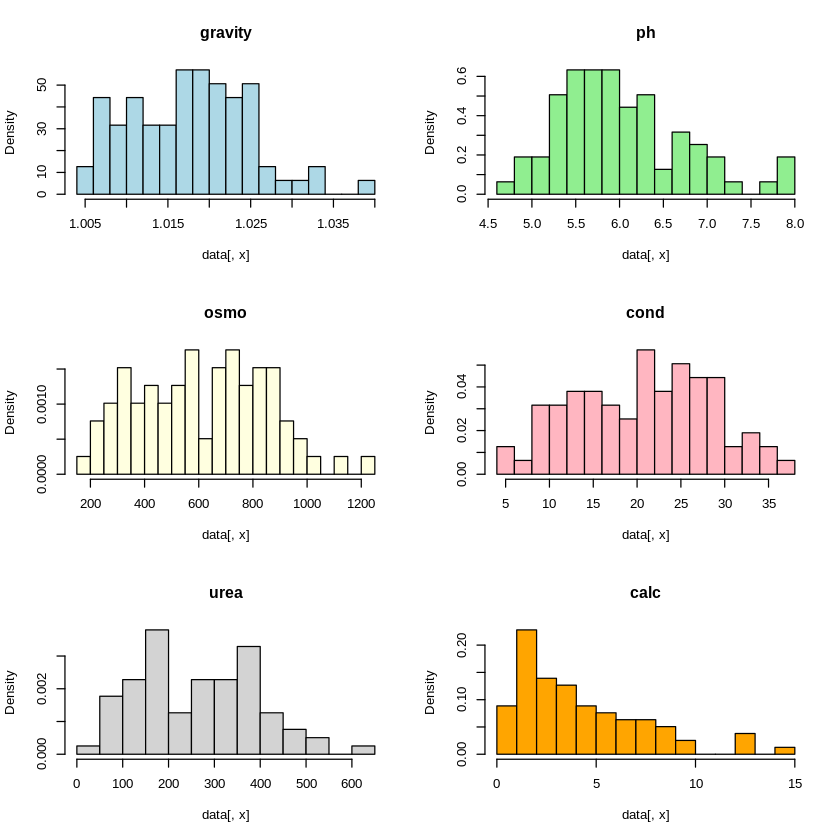

In [3]:
colors_ <- c("black", "lightblue", "lightgreen",
             "lightyellow", "lightpink", "lightgray", "orange")

par(mfrow = c(3, 2))

for (x in 2:7) {
  hist(data[,x], breaks = 15, probability = TRUE, col = colors_[x], border = "black", main=colnames(data[x]))
}

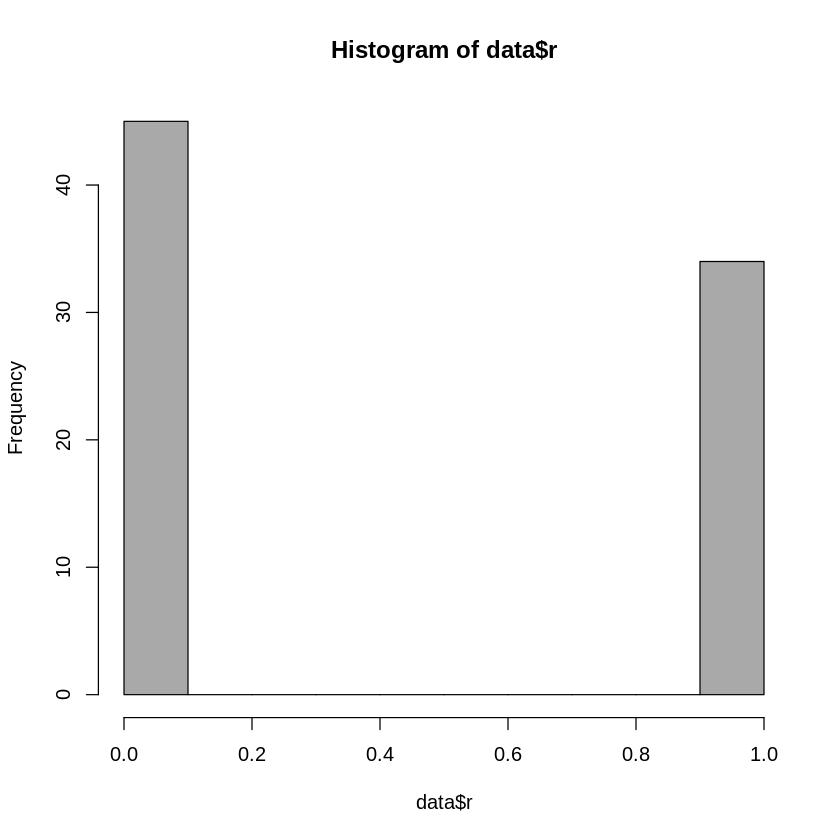

In [4]:
hist(data$r, col = "darkgray")

# Bayesian Networks

Often, when modeling, we have some causal interpretation of the variables. In our case, well-established science tells us which of these are likely to be dependent upon others. In situations where we have structure like this, or where we wish to learn the latent structure, we can utilize a Bayesian network. A Bayesian network is a class of graphical model which represents variables as nodes and conditional relationships with arcs (arrows). Reasons for the term 'Bayesian' include:

- The reliance on Bayes' theorem for conditioning as the basis for updating information.
- The subjective nature of choosing the variables' structure and directions.
- The ability to incorporate prior information.

It is traditionally very common to discretize variables in a Bayesian network, for mathematical convenience. It is also convenient to use Gaussian distributions around a linear-modeled mean (one for each category in a discrete-to-continuous relationship). <code>bnlearn</code> is a robust package of functions for creating and working with Bayesian networks in R, and is very convenient to work with when data are discrete or assumed to be Gaussian (or a mixture of both). To work with more customized distributions, we will model things more manually in <code>rstan</code>, and we will only use <code>bnlearn</code> to plot our directed acyclic diagram (DAG).

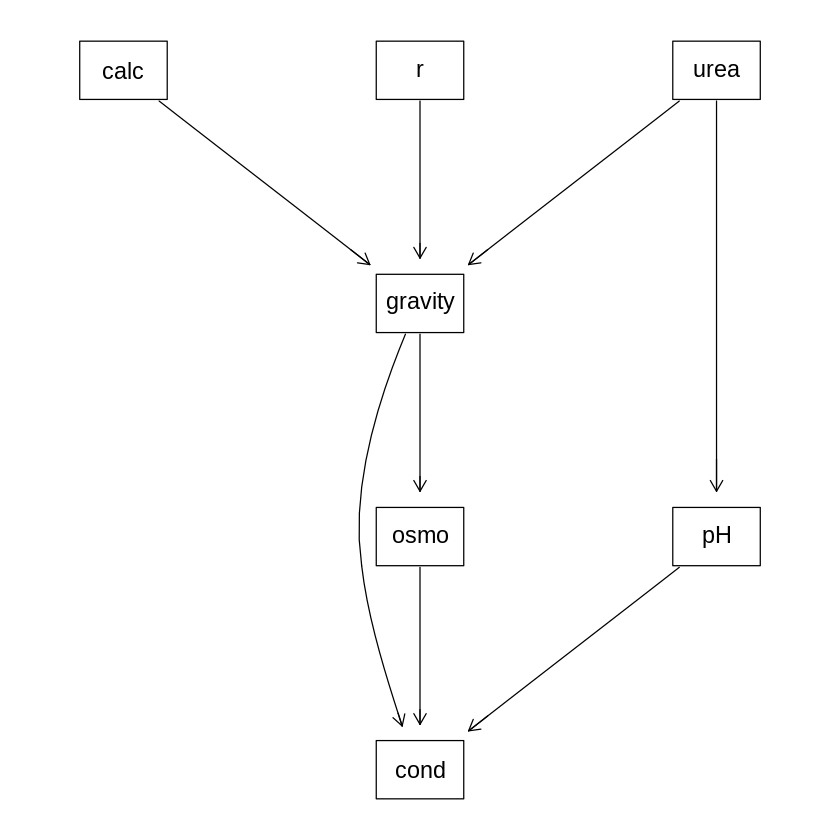

In [5]:
modelstr <- "[urea][r][calc][gravity|r:calc:urea][pH|urea][cond|gravity:osmo:pH][osmo|gravity]"
dag <- model2network(modelstr)
graphviz.plot(dag)

<code>calc</code> (calcium), <code>r</code> (presence of oxalate crystals) and <code>urea</code> all contribute to <code>gravity</code>, which measures the level of dissolved particles. <code>osmo</code> (osmotivity) depends on <code>gravity</code>, <code>ph</code> depends on <code>urea</code>, and <code>cond</code> (conductivity) depends on <code>gravity</code>, <code>osmo</code>, and <code>ph</code>. Of course, each of these variables also has an inherent amount of random variability. Forgive me if any of this is incorrect, I am not a urinalysis expert; but for the sake of demonstration, this structure will suffice.

If we had no prior knowledge of the relationships between variables, learning the structure from data could be accomplished through a variety of algorithms, and we could even use resampling methods in which a number of networks are fit, and arcs that appear with a particular frequency or greater retained in the final model.

# Implementation

The C++ code we provide to <code>stan</code>, through <code>rstan</code>, is structured in blocks. This includes <code>data{}</code>, <code>parameters{}</code>, <code>model{}</code>, and <code>generated quantities{}</code>, which we will go through one by one, and others that you can look into independently (<a href="https://mc-stan.org/docs/reference-manual/blocks.html#:~:text=A%20Stan%20program%20is%20organized%20into%20a%20sequence%20of%20named">user guide here</a>) include <code>functions{}</code>, <code>transformed data</code>, <code>initialization{}</code>, and <code>constraints{}</code>.

The <code>data{}</code> block declares the variables to be populated with the data that we will pass into the function which compiles the model, <code>stan()</code>, via a list. This will typically include at least an <code>N</code> variable and <code>y</code> variable, for number of observations and dependent variable respectively, but these can take on any names you desire.

<p>To declare an integer number of samples, we use <code>int &ltlower=0&gt N;</code>, where <code>&ltlower=0&gt</code> is an optional argument that constrains the values of the variable to be 0 or greater. For a binary variable, we could use <code>int &ltlower=0, upper=1&gt myvar;</code>, and for a non-integer number on the real line, we would use type <code>real</code> instead of <code>int</code>. A vector with elements of type <code>real</code> may be declared as <code>vector[N] myvector;</code>, where <code>N</code> represents the number of elements. For greater flexibility, you can create an array of the desired type with <code>N</code> elements using syntax such as <code>int myarray[N];</code> however, with a <code>vector</code>, you can take advantage of matrix-multiplication where possible, whereas with an array, you must always loop through the elements while working with it.</p>

We'll start simple, taking the <code>gravity</code> variable and modeling it as a Gaussian with no predictor variable. Our <code>data{}</code> block will look like this:

In [6]:
# data {
#   int<lower=0> N;
#   vector[N] y;
# }

The <code>parameters{}</code> block is for declaration of non-data variables (i.e., parameters) to be used in the modeling process. For the normal distribution we will use to model the data, we will declare the parameters <code>mu</code> and <code>sigma</code> as real-numbered variables, with <code>sigma</code> bounded at 0. Again, you could choose any other names, so long as they are fed into the normal distribution function in the appropriate positions when we get to the <code>model{}</code> block.

In [7]:
# parameters {
#   real mu;
#   real<lower=0> sigma;
# }

In the <code>model{}</code> block, parameters are mapped to the data to be fit via modeling functions. We can declare a prior distribution on these parameters, or let <code>stan</code> assign a flat prior by default. The <code>~</code> operator is used (as 'drawn from'), rather than <code>=</code>. For the sake of simplicity in this first example, we will not yet set priors on the parameters.

In [8]:
# model {
#   y ~ normal(mu, sigma);
# }

Finally, the <code>generated quantities{}</code> block is where we generate predictions from the fitted model. This is optional; if you are only interested in finding parameters, the <code>model{}</code> block is all you require, and I will show you how to extract them momentarily.

The variables used to store predictions must be declared at the top of this block. The differences between referring to a distribution in the <code>model{}</code> block and referring to a distribution in the <code>generated quantities{}</code> block are that:
1. In the <code>model{}</code> block we use the <code>~</code> operator whereas in the <code>generated quantities{}</code> block, we use <code>=</code>, and

2. When using the model to generate quantites, we append it with <code>_rng</code>.

In [9]:
# generated quantities {
#   vector[N] y_pred;
#   for (n in 1:N) {
#     y_pred[n] = normal_rng(mu, sigma);
#   }
# }

Putting it all together, we have compiled our C++ code for <code>stan</code>.

In [10]:
stan_code <- "
  data {
    int<lower=0> N;
    vector[N] y;
  }

  parameters {
    real mu;
    real<lower=0> sigma;
  }

  model {
    y ~ normal(mu, sigma);
  }

  generated quantities {
    vector[N] y_pred;
    for (n in 1:N) {
      y_pred[n] = normal_rng(mu, sigma);
    }
  }
"

The code is saved to the variable <code>stan_code</code>, which we will pass as the first argument to the <code>stan()</code> function in order to compile and fit the model. The list of data we're passing in consists of <code>N</code> and <code>y</code>, which are the number of observations and the <code>gravity</code> variable respectively. <code>chains</code> refers to the number of sampling chains to run, and <code>iter</code> refers to the number of samples to draw per chain while fitting the model, which will correspond to the number of samples generated by the <code>generated quantities{}</code> block. It is a good idea to run multiple chains, in case one or more is divergent. <code>warmup</code> tells it to discard a certain amount of leading samples in each chain, as it can take a while for the sampler to focus in on the optimal space.
<code>refresh=0</code> suppresses the output while sampling, and <code>cores</code> tells it how many processors to use.

In [11]:
N <- nrow(data)
data_list <- list(N=N, y=data$gravity)
model_fit <- stan(model_code = stan_code, data = data_list, warmup=1000,
                 iter = 3000, chains = 4, refresh = 0, cores = 4)

The returns of the function have been saved into the variable <code>model_fit</code>. The data type of this object is a class called 'stanfit', and simply typing it into the console will produce an output like the below, where we see the mean and standard deviation (plus various quantiles) of parameters and <code>y_pred</code> samples (which are listed across multiple columns in a matrix), plus some diagnostic information about the sampling. I've wrapped it in the <code>print</code> function in order to control the number of digits after the decimals.

In [12]:
class(model_fit)
print(model_fit, digits=5)

[1] "stanfit"
attr(,"package")
[1] "rstan"

Inference for Stan model: anon_model.
4 chains, each with iter=3000; warmup=1000; thin=1; 
post-warmup draws per chain=2000, total post-warmup draws=8000.

                mean se_mean      sd      2.5%       25%       50%       75%
mu           1.01811 0.00001 0.00083   1.01644   1.01757   1.01811   1.01867
sigma        0.00735 0.00001 0.00060   0.00625   0.00693   0.00731   0.00772
y_pred[1]    1.01821 0.00008 0.00742   1.00378   1.01330   1.01823   1.02312
y_pred[2]    1.01813 0.00008 0.00742   1.00391   1.01313   1.01807   1.02299
y_pred[3]    1.01803 0.00009 0.00751   1.00326   1.01315   1.01812   1.02308
y_pred[4]    1.01823 0.00008 0.00748   1.00337   1.01326   1.01826   1.02322
y_pred[5]    1.01797 0.00008 0.00738   1.00357   1.01295   1.01797   1.02292
y_pred[6]    1.01808 0.00008 0.00744   1.00337   1.01319   1.01813   1.02309
y_pred[7]    1.01816 0.00009 0.00741   1.00346   1.01331   1.01811   1.02300
y_pred[8]    1.01816 0.00008 0.00749   1.00392   1.01313   1.01810   1.023

The trace plot is a common diagnostic tool, and ideally displays a pattern that looks stationary and noisy, such as the following:

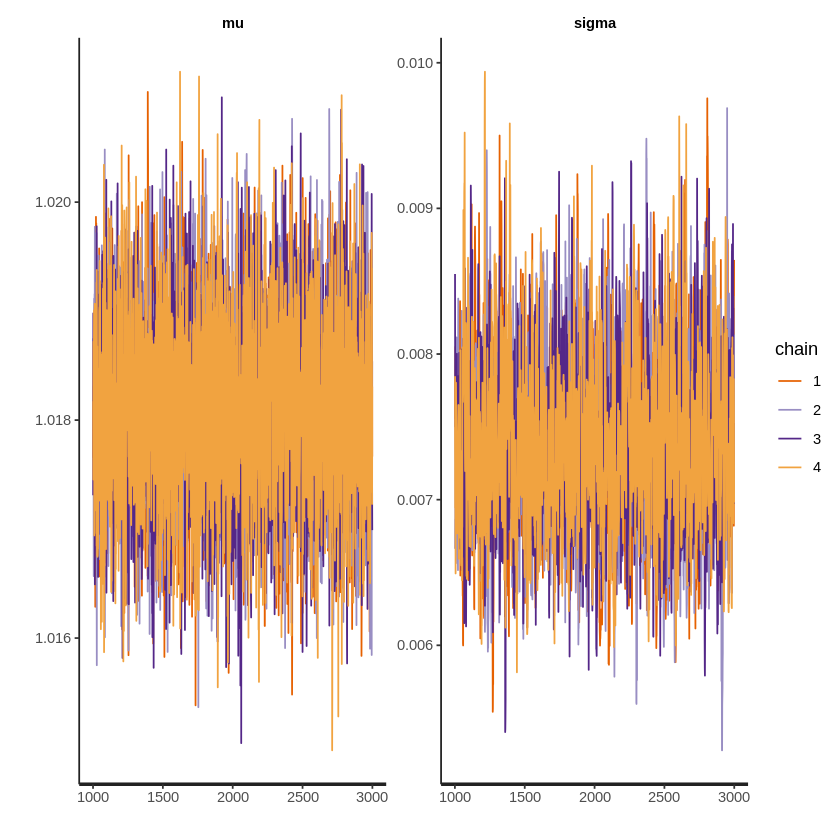

In [13]:
stan_trace(model_fit, pars=c("mu", "sigma"))

We would expect our parameters to have fairly normal distributions, and they do.

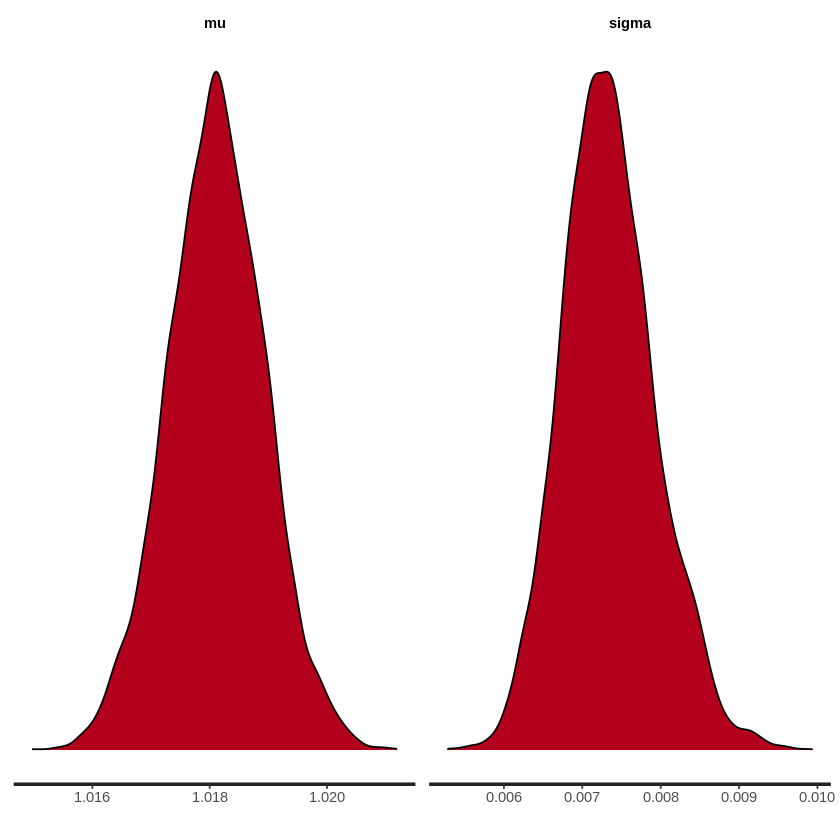

In [14]:
stan_dens(model_fit, pars=c('mu', 'sigma'))

To get the samples (including parameter values) into a more workable format, we'll use the <code>extract</code> function. We could wrap it in <code>as.data.frame</code> if desired. Note that it is more efficient to extract once and then work with that than to work with the non-extracted data repeatedly.

Upon extracting, the samples for parameters such as <code>mu</code> and <code>sigma</code> can be accessed such as below, and our generated quantities <code>y_pred</code> accessed as <code>posterior_samples$y_pred</code>.

In [15]:
posterior_samples <- extract(model_fit)

mu <- mean(posterior_samples$mu)
sigma <- mean(posterior_samples$sigma)

mu
sigma

[1] 1.018113

[1] 0.007346384

The following is a histogram of the predictions.

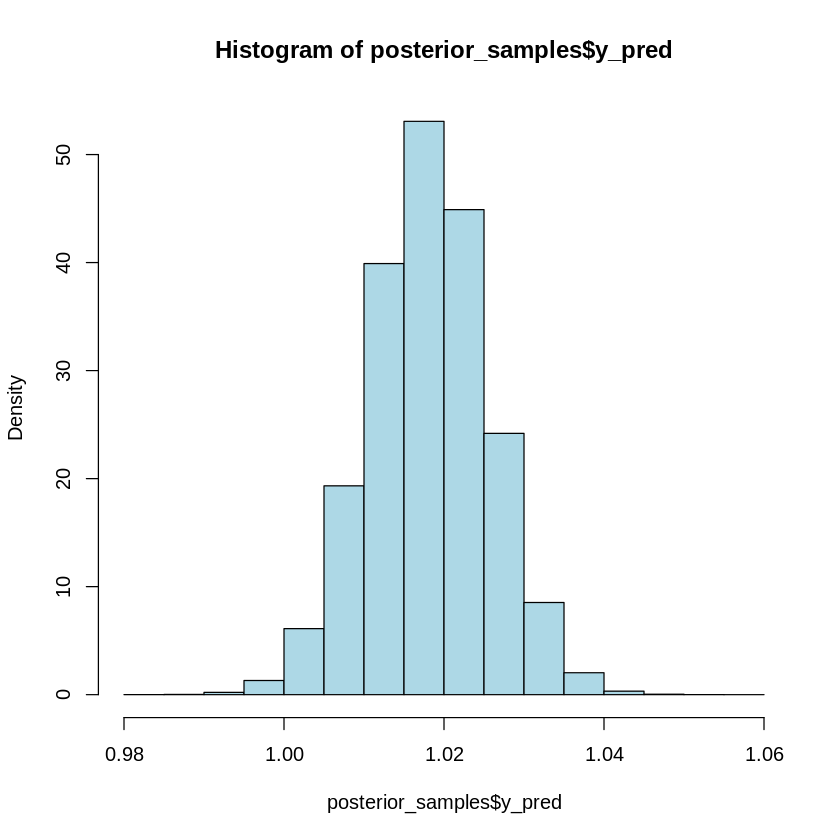

In [16]:
hist(posterior_samples$y_pred, col="lightblue", probability = TRUE)

And the following is a histogram of the values found for the sigma parameter during sampling. This is one of the nice things about Bayesian analysis; your parameters have probability distributions, quantifying uncertainty.

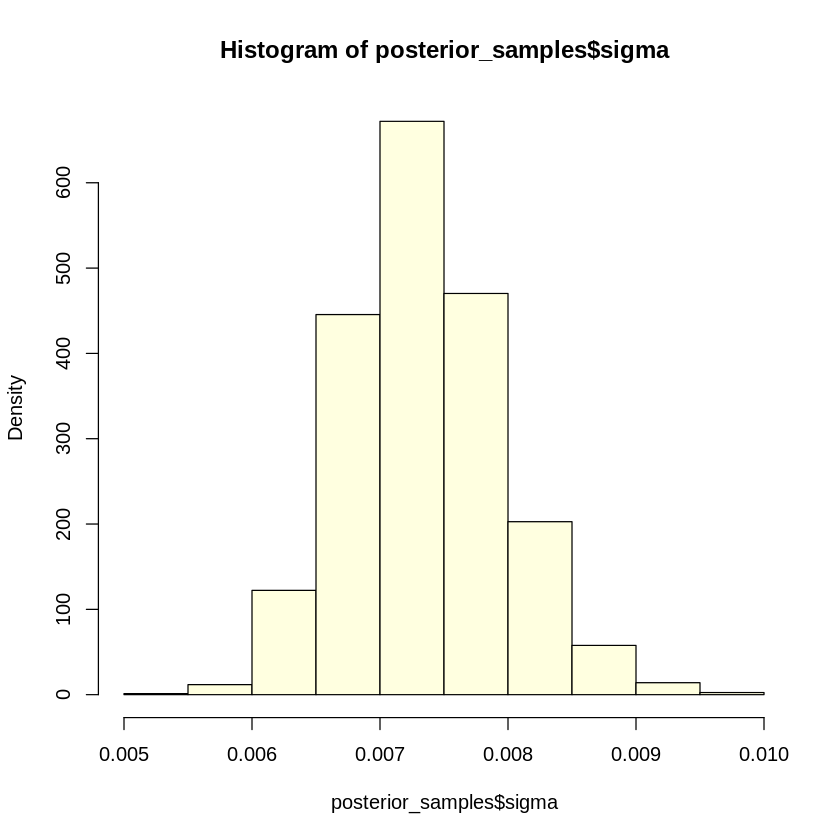

In [17]:
hist(posterior_samples$sigma, col="lightyellow", probability = TRUE)

# Doing it With Priors

Now we will modify the above to incorporate prior distributions over parameters. We'll use the mean and standard deviation of the parameters <code>mu</code> and <code>sigma</code> to define the prior distributions over those parameters in the following, and pretend we have some new data by drawing samples from our dataset.

In [18]:
prior_mu_mean <- mean(posterior_samples$mu)
prior_mu_sigma <- sd(posterior_samples$mu)
prior_sigma_mean <- mean(posterior_samples$sigma)
prior_sigma_sigma <- sd(posterior_samples$sigma)

prior_mu_mean
prior_mu_sigma
prior_sigma_mean
prior_sigma_sigma

y_sampled <- sample(data$gravity, 15)

[1] 1.018113

[1] 0.000829073

[1] 0.007346384

[1] 0.000602656

The C++ code will be saved into the <code>stan_code</code> variable as below. The following has changed:
- New data variables introduced; we will use these to pass in the previously found parameters so that they can be used in priors. <code>mu_mean</code> refers to the mean of the <code>mu</code> parameter (I know it's a little confusing), <code>mu_sigma</code> refers to its standard deviation, etc.

- Two new lines in the <code>model{}</code> block. <code>mu</code> and <code>sigma</code> of the <code>y</code> variable are themselves being modeled now, though we'll let the prior for those parameters be flat.

In [19]:
stan_code <- "
  data {
    int<lower=0> N;
    vector[N] y;
    real prior_mu_mean;
    real prior_mu_sigma;
    real prior_sigma_mean;
    real prior_sigma_sigma;
  }

  parameters {
    real mu;
    real<lower=0> sigma;
  }

  model {
    mu ~ normal(prior_mu_mean, prior_mu_sigma);
    sigma ~ normal(prior_sigma_mean, prior_sigma_sigma);
    y ~ normal(mu, sigma);
  }

  generated quantities {
    vector[N] y_pred;
    for (n in 1:N) {
      y_pred[n] = normal_rng(mu, sigma);
    }
  }
"

In [20]:
y_sampled <- sample(data$gravity, 15)
N <- length(y_sampled)
data_list <- list(N = N,
                  y = y_sampled,
                  prior_mu_mean = prior_mu_mean,
                  prior_mu_sigma = prior_mu_sigma,
                  prior_sigma_mean = prior_sigma_mean,
                  prior_sigma_sigma = prior_sigma_sigma)
model_fit <- stan(model_code = stan_code, data = data_list, warmup=1000,
                 iter = 3000, chains = 4, refresh = 0, cores = 4)

You could then proceed to run diagnostics, and extract and analyze the parameters and predictions. We've got a lot to do, so I'll keep it moving accordingly.

# Probabilistic Linear Modeling

The probabilistic specification of a single-variable linear model, with normally distributed data, is expressed:

- $y \sim N(\alpha + \beta x, ~\sigma)$

meaning that the mean of the normally distributed result is equal to the intercept of the model $\alpha$ plus the sum of the x-variable coefficient $\beta$ times the value $x_i$ of the vector $x$, for each $x_i$ in $x$. The interpretation is in sync with least squares, as that kind of problem is how Gauss discovered the normal distribution, but I digress.

Rather than solve with least squares, we will solve with Bayesian inference, which will return probability distributions over parameters. We will incorporate multiple terms into our regressions, and could define polynomial or arbitrarily complex functions which we then model with noise such as above. We are not restricted to using a normal distribution to distribute the noise. In fact, a popular way to promote robustness to outliers is to use a t-distribution, as we'll explore later on. A complete list of built-in distributions and their parameters can be found in this <a href="https://mc-stan.org/docs/2_18/functions-reference/index.html#overview">user guide</a>.

Below, we'll model <code>osmo</code> as a linear function of <code>gravity</code>. To keep it simple, we'll avoid setting priors, but we'll declare them, and allow <code>stan</code> to default to flat ones. If not for the experimentation above, I would model <code>sigma</code> from a distribution that is strictly positive, but we have seen that it has a very narrow range, so I'll use a normal.

In [21]:
stan_code <- "
data {
  int<lower=0> N;
  vector[N] gravity;
  vector[N] osmo;
}

parameters {
    real alpha;
    real beta;
    real<lower=0> sigma;

    real alpha_mu;
    real alpha_sigma;
    real beta_mu;
    real beta_sigma;
    real<lower=0> sigma_mu;
    real<lower=0> sigma_sigma;
}

model {
    // Priors
    alpha ~ normal(alpha_mu, alpha_sigma);
    beta ~ normal(beta_mu, beta_sigma);
    sigma ~ normal(sigma_mu, sigma_sigma);

    // Likelihood
    osmo ~ normal(alpha + beta * gravity, sigma);
}

generated quantities {
  vector[N] osmo_pred;
  for (n in 1:N)
    osmo_pred[n] = normal_rng(alpha + beta * gravity[n], sigma);
}
"

In [ ]:
N <- nrow(data)
data_list <- list(N=N, gravity=data$gravity, osmo=data$osmo)
model_fit <- stan(model_code = stan_code, data = data_list, warmup = 1000,
                 iter = 3000, chains = 4, refresh = 0, cores = 4)

Next, we'll plot the results. <code>posterior_samples$osmo_pred</code> is actually a matrix, with 8000 rows (we ran 2000 iterations excluding the <code>warmup</code> for 4 chains), and 79 columns; one column for each instance of x (<code>gravity</code>). This is a consequence of setting <code>N</code> to the number of rows in our dataset. To get the predicted mean across samples, we use the <code>apply</code> function to take the mean column-wise, across rows.

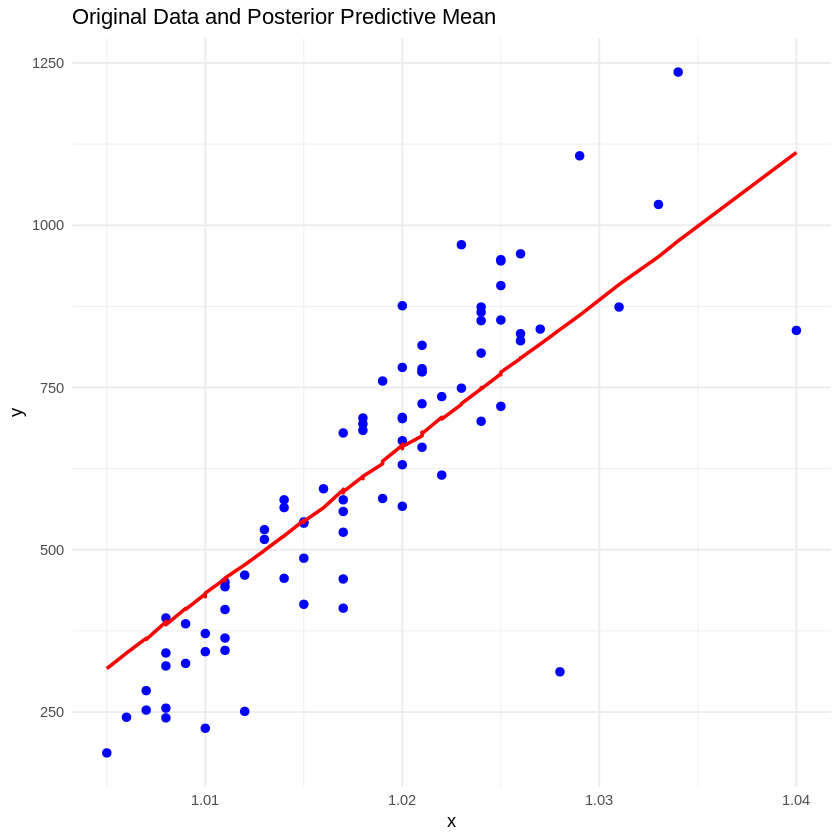

In [23]:
posterior_samples <- extract(model_fit)
y_pred_samples <- posterior_samples$osmo_pred
y_pred_mean <- apply(y_pred_samples, 2, mean)

ggplot(data.frame(x = data$gravity, y = data$osmo, y_pred = y_pred_mean), aes(x = x)) +
  geom_point(aes(y = y), color = "blue", size = 2) +
  geom_line(aes(y = y_pred), color = "red", linewidth = 1) +
  labs(title = "Original Data and Posterior Predictive Mean",
       x = "x", y = "y") +
  theme_minimal()

The results look good, though there is a clear tilt toward what could be described as a couple of outliers (not necessarily in the univariate sense, but in the joint distribution). For fun, let's assume that we have good reason to disregard these outliers. An alternative to removing them from the data or overwriting them with imputed values is to adjust the tails of the distribution we are using to model the noise. The t-distribution allocates more mass to the tails, so it will have less problem setting a regression line which practically ignores the outliers. A word of caution though, is that the lower the degrees of freedom, the more correlated the simulated data will become. I know from prior experimentation with the data that about 10 degrees of freedom will work well, and to keep it simple, I will set this deterministically.

Our changes are as follows. Instead of the line:
- <code>osmo ~ normal(alpha + beta * gravity, sigma);</code>

we now have:
- <code>osmo ~ student_t(10, alpha + beta * gravity, sigma);</code>

and instead of the line:
- <code>osmo_pred[n] = normal_rng(alpha + beta * gravity[n], sigma);</code>

we now have:
- <code>osmo_pred[n] = student_t_rng(10, alpha + beta * gravity[n], sigma);</code>

In [24]:
stan_code <- "
data {
  int<lower=0> N;
  vector[N] gravity;
  vector[N] osmo;
}

parameters {
    real alpha;
    real beta;
    real<lower=0> sigma;

    real alpha_mu;
    real alpha_sigma;
    real beta_mu;
    real beta_sigma;
    real<lower=0> sigma_mu;
    real sigma_sigma;
}

model {
    // Priors
    alpha ~ normal(alpha_mu, alpha_sigma);
    beta ~ normal(beta_mu, beta_sigma);
    sigma ~ normal(sigma_mu, sigma_sigma);

    // Likelihood
    osmo ~ student_t(10, alpha + beta * gravity, sigma);
}

generated quantities {
  vector[N] osmo_pred;
  for (n in 1:N)
    osmo_pred[n] = student_t_rng(10, alpha + beta * gravity[n], sigma);
}
"

In [ ]:
N <- nrow(data)
data_list <- list(N=N, gravity=data$gravity, osmo=data$osmo)
model_fit <- stan(model_code = stan_code, data = data_list,
                  chains = 4, iter = 3000, warmup = 1000,
                  refresh = 0, cores = 4)

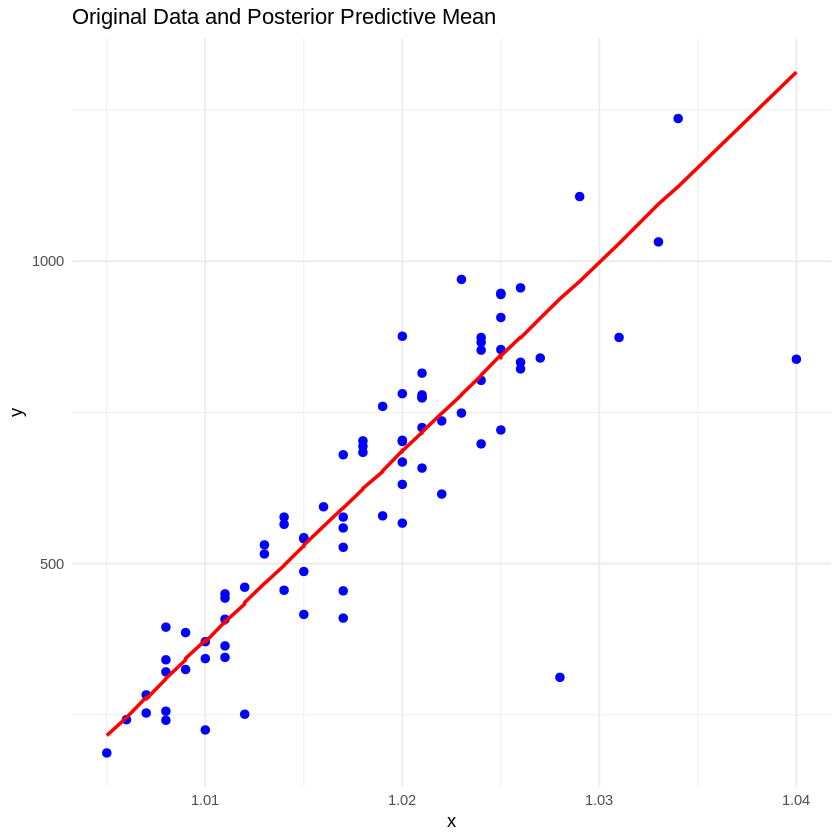

In [26]:
posterior_samples <- extract(model_fit)
y_pred_samples <- posterior_samples$osmo_pred
y_pred_mean <- apply(y_pred_samples, 2, mean)

ggplot(data.frame(x = data$gravity, y = data$osmo, y_pred = y_pred_mean), aes(x = x)) +
  geom_point(aes(y = y), color = "blue", size = 2) +
  geom_line(aes(y = y_pred), color = "red", linewidth = 1) +
  labs(title = "Original Data and Posterior Predictive Mean",
       x = "x", y = "y") +
  theme_minimal()

You can see that the slope line pays less mind to the outliers.

# Putting it All Together

Let's replot our DAG as a reminder of the causal relationships among variables.

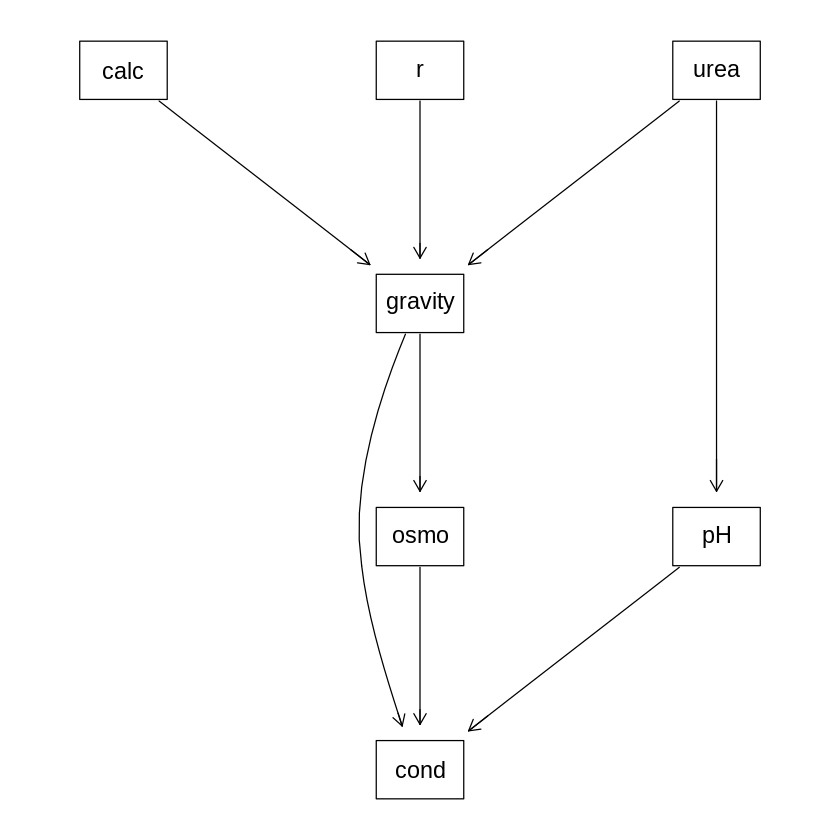

In [27]:
graphviz.plot(dag)

The data will be scaled, because it increases the speed of execution, and makes it easy to apply a normal prior. I will use N(0,1) priors on the <code>alpha</code> and <code>beta</code> parameters, largely for simplicity (feel free to tune them). On the <code>sigma</code> parameters, I will apply an exponential distribution to constrain the results to positive values, but I will let <code>stan</code> apply a flat prior to that, and find the parameter values based on the data. To recover the original scale of data and parameters, we use:

- Data: $x = z \sigma + \mu$
- Slope: $\beta = \beta_{std} \cdot \frac{\sigma_y}{\sigma_x}$
- Intercept: $\alpha = \mu_y - \beta \cdot \mu_x$

<code>r</code> will be modeled as Bernoulli-distributed. <code>osmo</code>, as a function of <code>gravity</code>, will be t-distributed. For <code>calc</code>, <code>urea</code>, and <code>cond</code>, we will use folded normal distributions, which take any values peeking below zero and add them to the lower tail by flipping them to positive (we'll do this after restoring the original scale). Alternatives to this would include creating a function for a truncated normal (which has a formal PDF), or a half-normal, which is a folded normal with the mean set to 0. The rest of our distributions will be modeled to have plain normal residuals.

There will be a lot of variables, so a system of nomenclature is important. An alternative in many cases would be to pass in a matrix and work with column indices, but I have opted to save each variable as a vector and each parameter as a scalar.

Variables starting with <code>mu</code> or <code>sigma</code> are fed into normal distributions with no linear predictor, and are appended by an underscore followed by the name of the corresponding data variable. <code>lambda</code> followed by an underscore and a variable name represents the underlying parameter of a <code>sigma</code> parameter, because they are modeled by exponentials. <code>alpha</code> and <code>beta</code> variables feed linear models, and are followed by an underscore and at least one predictor variable, before ending with an underscore and the predicted variable. For example, <code>alpha_gravity_osmo_cond</code> means the <code>alpha</code> parameter for the multiple regression relationship with <code>gravity</code> and <code>osmo</code> as independent variables, and <code>cond</code> as the dependent variable. <code>beta</code> parameters all have a one to one relationship between predictor and predicted.

Note that in the <code>generated quantities{}</code> block below, we make predictions in a sequence which allows for the dependencies among variables; i.e., a variable cannot be predicted before its prerequisites are predicted. Our reason for using the prediction of one variable to feed another, rather than using our x variables from the data, as above, is so that the conditional relationship dependencies are properly taken into account in the simulated data.

In [28]:
scaled_calc <- as.vector(scale(data$calc))
scaled_gravity <- as.vector(scale(data$gravity))
scaled_ph <- as.vector(scale(data$ph))
scaled_osmo <- as.vector(scale(data$osmo))
scaled_cond <- as.vector(scale(data$cond))
scaled_urea <- as.vector(scale(data$urea))

In [29]:
stan_code <- "
  data {
    int<lower=0> N;
    int<lower=0, upper=1> r[N];
    vector[N] gravity;
    vector[N] ph;
    vector[N] osmo;
    vector[N] cond;
    vector[N] urea;
    vector[N] calc;
  }

  parameters {
    real<lower=0, upper=1> theta_r;

    real mu_calc;
    real sigma_calc;

    real mu_urea;
    real<lower=0> sigma_urea;

    real alpha_gravity_osmo;
    real alpha_gravity_osmo_cond;
    real alpha_urea_r_calc_gravity;
    real alpha_urea_ph;

    real beta_gravity_osmo;
    real beta_gravity_cond;
    real beta_osmo_cond;
    real beta_urea_gravity;
    real beta_urea_ph;
    real beta_r_gravity;
    real beta_calc_gravity;

    real<lower=0> sigma_gravity_osmo;
    real<lower=0> sigma_gravity_osmo_cond;
    real<lower=0> sigma_urea_r_calc_gravity;
    real<lower=0> sigma_urea_ph;

    real<lower=0> lambda_gravity_osmo;
    real<lower=0> lambda_gravity_osmo_cond;
    real<lower=0> lambda_urea_r_calc_gravity;
    real<lower=0> lambda_urea_ph;
  }

  model {

    alpha_gravity_osmo ~ normal(0,1);
    alpha_gravity_osmo_cond ~ normal(0,1);
    alpha_urea_r_calc_gravity ~ normal(0,1);
    alpha_urea_ph ~ normal(0,1);

    beta_gravity_osmo ~ normal(0,1);
    beta_gravity_cond ~ normal(0,1);
    beta_osmo_cond ~ normal(0,1);
    beta_urea_gravity ~ normal(0,1);
    beta_urea_ph ~ normal(0,1);
    beta_r_gravity ~ normal(0,1);
    beta_calc_gravity ~ normal(0,1);

    sigma_gravity_osmo ~ exponential(lambda_gravity_osmo);
    sigma_gravity_osmo_cond ~ exponential(lambda_gravity_osmo_cond);
    sigma_urea_r_calc_gravity ~ exponential(lambda_urea_r_calc_gravity);
    sigma_urea_ph ~ exponential(lambda_urea_ph);

    for (n in 1:N) {
      r[n] ~ bernoulli(theta_r);
    }

    urea ~ normal(mu_urea, sigma_urea);
    calc ~ normal(mu_calc, sigma_calc);

    ph ~ normal(alpha_urea_ph +
                beta_urea_ph * urea,
                sigma_urea_ph);

    cond ~ normal(alpha_gravity_osmo_cond +
                  beta_gravity_cond * gravity +
                  beta_osmo_cond * osmo,
                  sigma_gravity_osmo_cond);

    osmo ~ student_t(10, alpha_gravity_osmo +
                     beta_gravity_osmo * gravity,
                     sigma_gravity_osmo);

    for (n in 1:N) {
      gravity[n] ~ normal(alpha_urea_r_calc_gravity +
                      beta_urea_gravity * urea +
                      beta_r_gravity * r[n] +
                      beta_calc_gravity * calc,
                      sigma_urea_r_calc_gravity);
    }
  }

  generated quantities {

    vector[N] r_pred;
    vector[N] gravity_pred;
    vector[N] ph_pred;
    vector[N] osmo_pred;
    vector[N] cond_pred;
    vector[N] urea_pred;
    vector[N] calc_pred;

    for (n in 1:N) {

      r_pred[n] = bernoulli_rng(theta_r);
      urea_pred[n] = normal_rng(mu_urea, sigma_urea);
      calc_pred[n] = normal_rng(mu_calc, sigma_calc);

      gravity_pred[n] = normal_rng(alpha_urea_r_calc_gravity +
                        beta_urea_gravity * urea_pred[n] +
                        beta_r_gravity * r_pred[n] +
                        beta_calc_gravity * calc_pred[n],
                        sigma_urea_r_calc_gravity);

      ph_pred[n] = normal_rng(alpha_urea_ph +
                              beta_urea_ph * urea_pred[n],
                              sigma_urea_ph);

      osmo_pred[n] = student_t_rng(10, alpha_gravity_osmo +
                                   beta_gravity_osmo * gravity_pred[n],
                                   sigma_gravity_osmo);

      cond_pred[n] = normal_rng(alpha_gravity_osmo_cond +
                               beta_gravity_cond * gravity_pred[n] +
                               beta_osmo_cond * osmo_pred[n],
                               sigma_gravity_osmo_cond);
    }
  }
"

In [30]:
N <- nrow(data)
data_list <- list(N=N, r=data$r, calc=scaled_calc,
                  gravity=scaled_gravity, ph=scaled_ph,
                  osmo=scaled_osmo, cond=scaled_cond, urea=scaled_urea)
model_fit <- stan(model_code = stan_code, data = data_list,
                  chains = 4, iter = 5000, warmup = 1000,
                  refresh = 0, cores = 4)

'pars' not specified. Showing first 10 parameters by default.



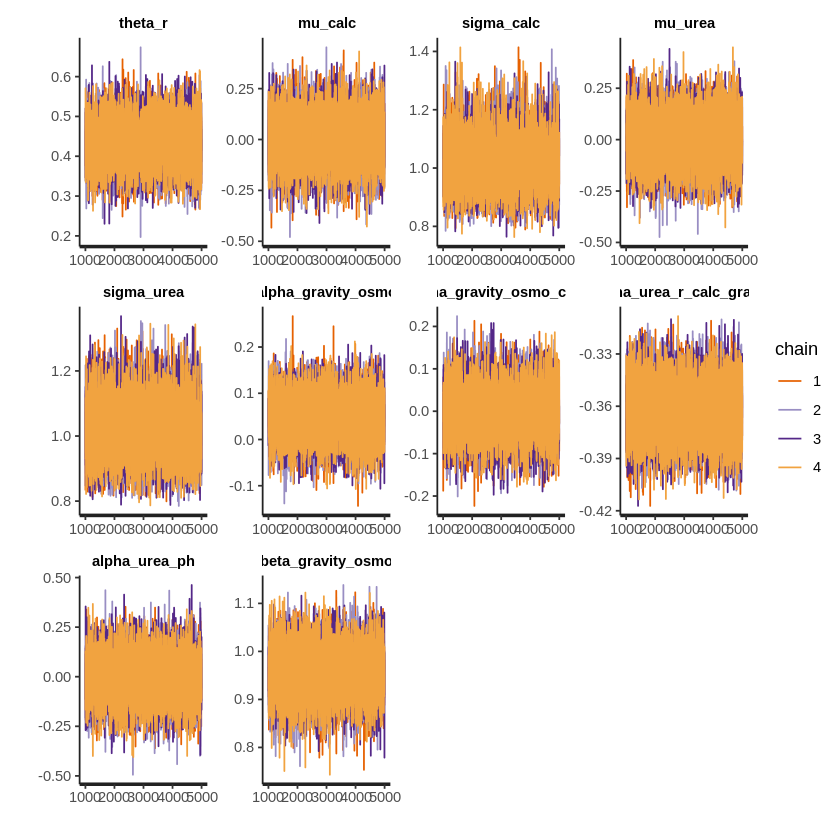

In [31]:
traceplot(model_fit)

'pars' not specified. Showing first 10 parameters by default.



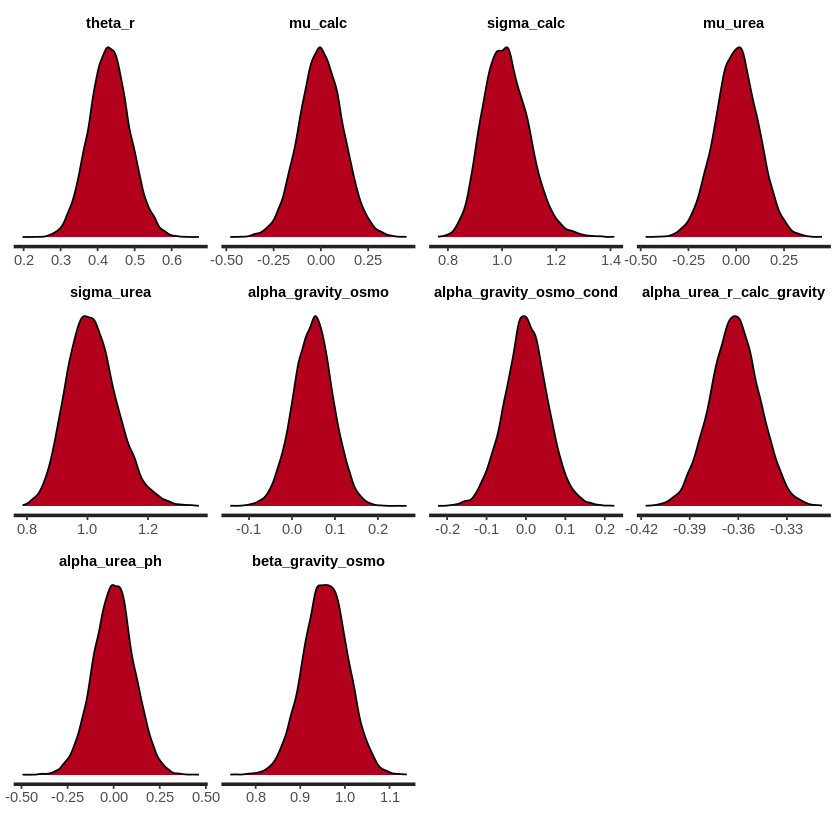

In [32]:
stan_dens(model_fit)

Below, we unpack the results and rescale the predicted quantities, flipping negative quantities to positive for the folded normals.

In [33]:
posterior_samples <- extract(model_fit)

unscaled_calc_pred <- abs(posterior_samples$calc_pred * sd(data$calc) + mean(data$calc))
unscaled_gravity_pred <- posterior_samples$gravity_pred * sd(data$gravity) + mean(data$gravity)
unscaled_ph_pred <- posterior_samples$ph_pred * sd(data$ph) + mean(data$ph)
unscaled_osmo_pred <- abs(posterior_samples$osmo_pred * sd(data$osmo) + mean(data$osmo))
unscaled_cond_pred <- abs(posterior_samples$cond_pred * sd(data$cond) + mean(data$cond))
unscaled_urea_pred <- abs(posterior_samples$urea_pred * sd(data$urea) + mean(data$urea))

And then inspect the data.

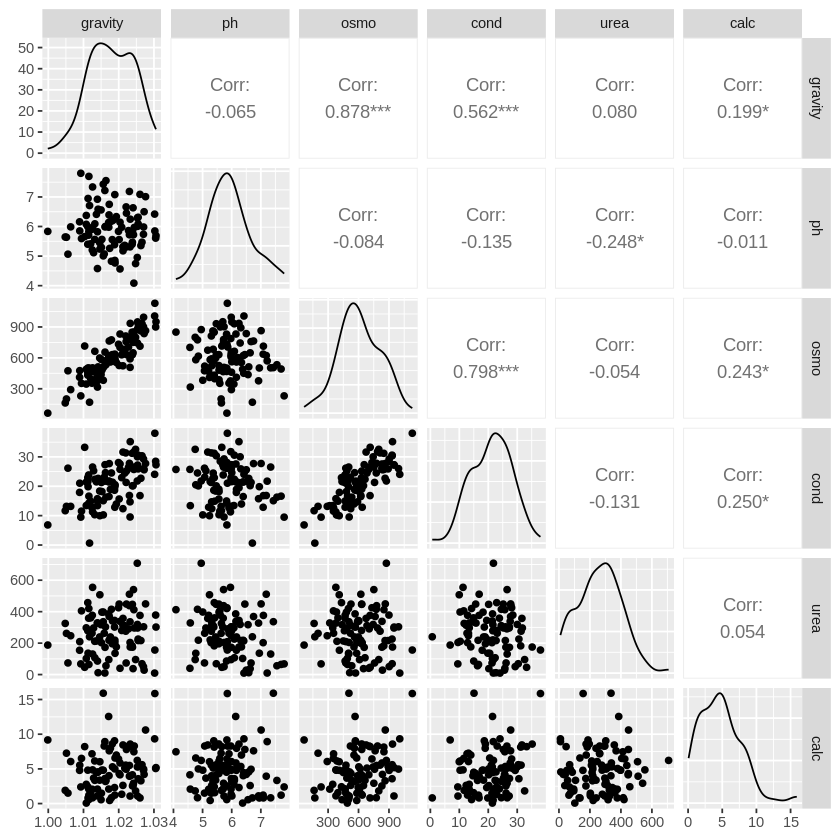

In [34]:
pred_df <- data.frame(cbind(as.vector(unscaled_gravity_pred), as.vector(unscaled_ph_pred),
                                as.vector(unscaled_osmo_pred), as.vector(unscaled_cond_pred),
                                as.vector(unscaled_urea_pred), as.vector(unscaled_calc_pred)))

colnames(pred_df) <- c('gravity', 'ph', 'osmo',
                       'cond', 'urea', 'calc')

sampled_rows <- pred_df[sample(nrow(pred_df), 100, replace = TRUE), ]
ggpairs(sampled_rows)

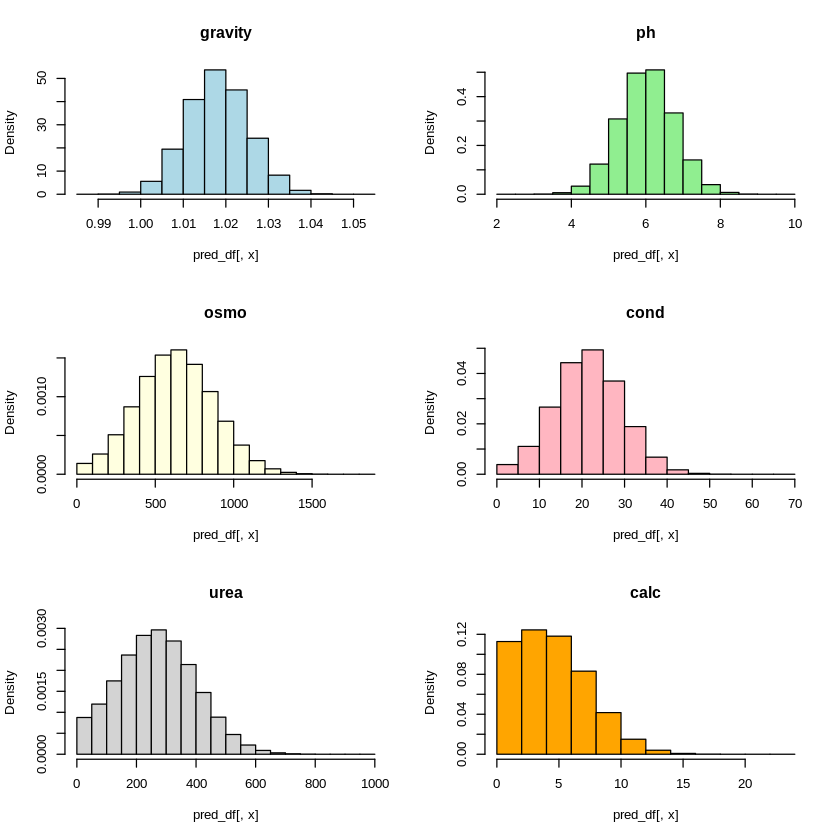

In [35]:
colors_ <- c("lightblue", "lightgreen", "lightyellow",
             "lightpink", "lightgray", "orange")

par(mfrow = c(3, 2))

for (x in 1:6) {
  hist(pred_df[,x], breaks = 15, probability = TRUE, col = colors_[x], border = "black", main=colnames(pred_df[x]))
}

Although packages like <code>bnlearn</code> offer built-in functions for the calculation of conditional probabilities, and extraction of conditional joint probability distributions, we are doing things more from scratch because of the custom distributions. However, most of the work is already done; we can now simply infer probabilities as proportions from the simulated data. The fidelity of this kind of analysis depends on the size of the simulated data, which is why we generated a lot of samples.

Below, for example, we get a point estimate of the probability that <code>urea</code> is greater than or equal to 400 while <code>cond</code> is between 30 and 40.

In [36]:
filtered_df <- subset(pred_df, urea >= 400 & cond >= 30 & cond <= 40)
nrow(filtered_df)
nrow(pred_df)
round(nrow(filtered_df) / nrow(pred_df),4)

[1] 26049

[1] 1264000

[1] 0.0206

Then for richer analysis, visualize the conditional probability distributions; first individually:

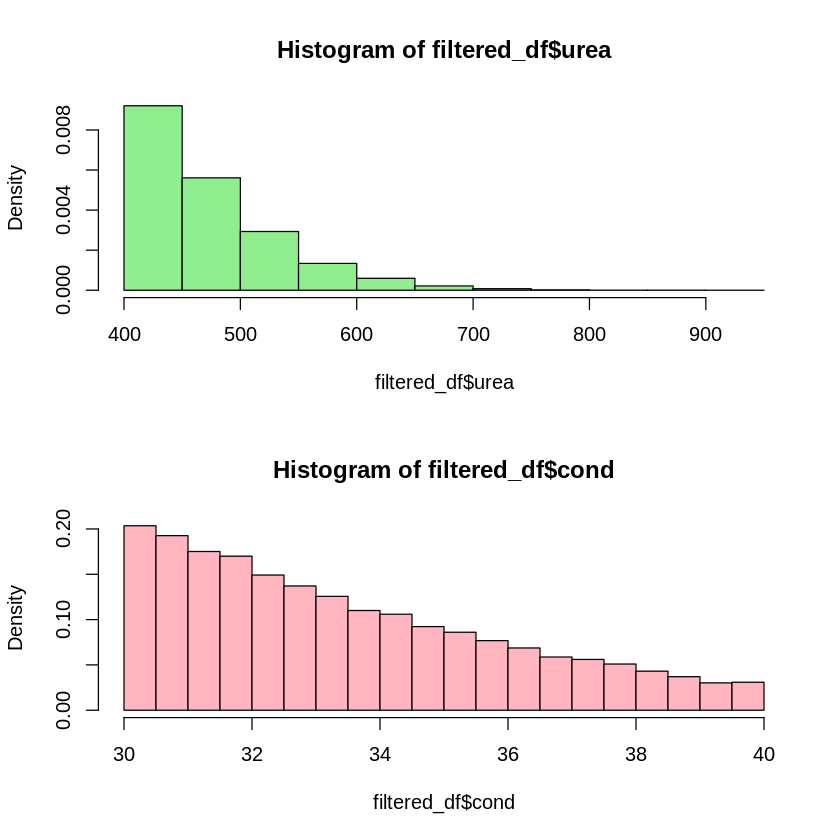

In [37]:
par(mfrow = c(2, 1))
hist(filtered_df$urea, probability = TRUE, col="lightgreen")
hist(filtered_df$cond, probability = TRUE, col="lightpink")

And then in joint fashion.

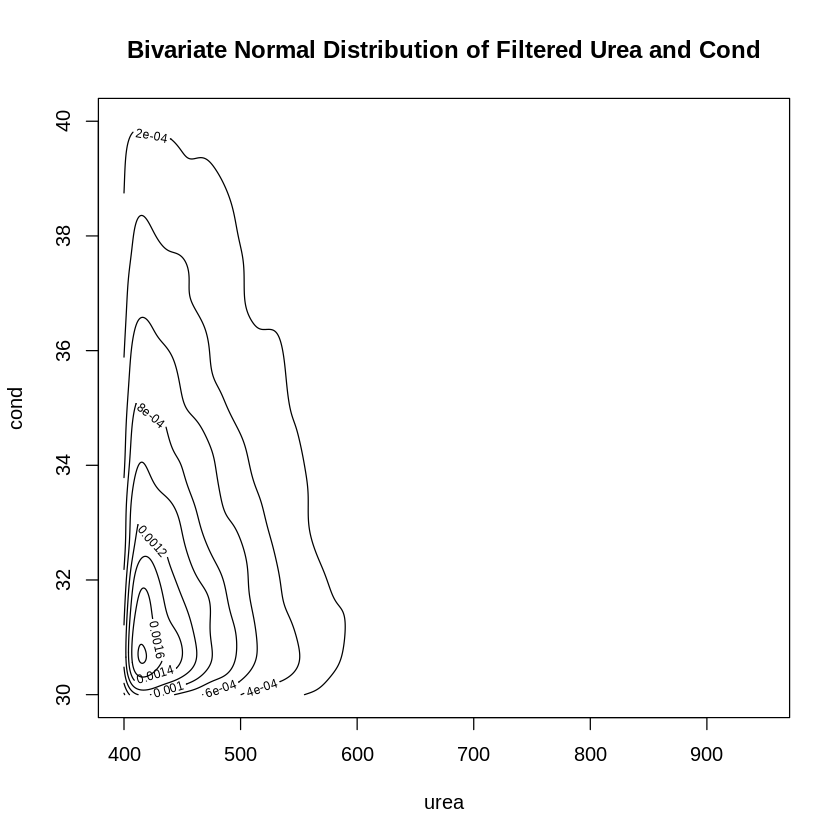

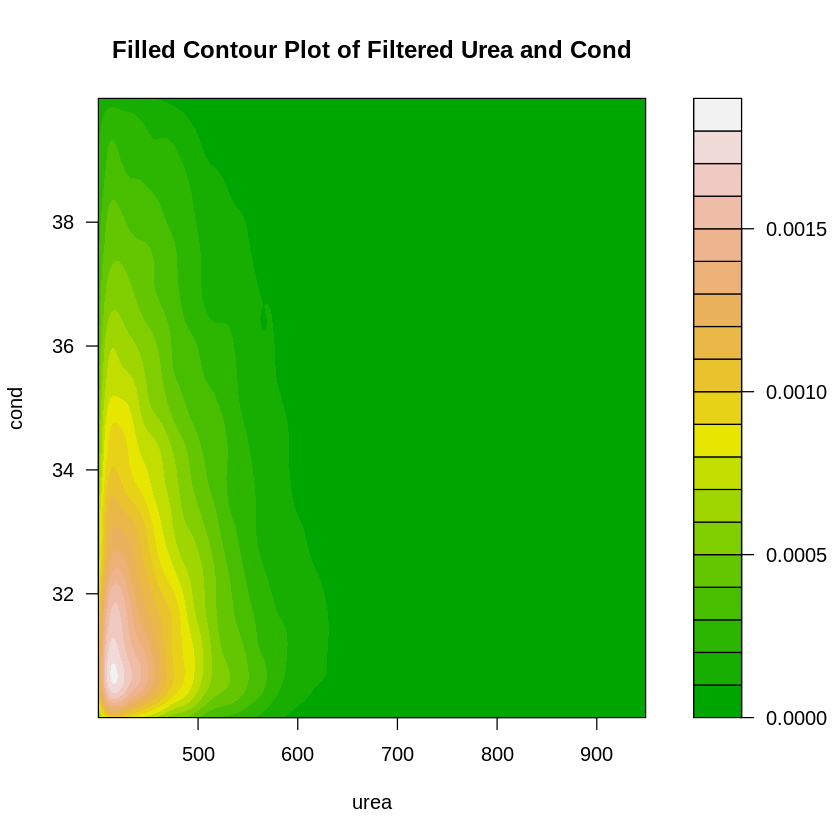

In [39]:
density_estimate <- kde2d(filtered_df$urea, filtered_df$cond, n = 1000)

contour(density_estimate, main = "Bivariate Normal Distribution of Filtered Urea and Cond",
        xlab = "urea", ylab = "cond")

filled.contour(density_estimate, color.palette = terrain.colors,
               plot.title = title(main = "Filled Contour Plot of Filtered Urea and Cond",
                                  xlab = "urea", ylab = "cond"))

And there you have it. We have covered a lot of ground, and in concise fashion. If you haven't seen the earlier articles in the series, they offer lengthier explanations, and make much greater use of built-in functions, through <code>pymc</code> for probabilistic programming, <code>bambi</code> for linear modeling, and <code>bnlearn</code> for Bayesian networks. The next series is on generalized linear models with <code>rstan</code>, and a summary article can be found <a href="https://nbviewer.org/github/pw598/Articles/blob/main/GLMs%20in%20RStan%20IV%20-%20GLMs%20in%20RStan%20Summary.ipynb">here</a>.

# References

<u>Books:</u>

- Gelman, A., Carlin, J., Stern, H., Rubin, D., Dunson, D., & Vehtari, A. (1995). Bayesian Data Analysis (3rd ed.). https://www.researchgate.net/publication/46714374_Bayesian_data_analysis

- McElreath, R. (2017). Statistical Rethinking (2nd ed.). https://github.com/Booleans/statistical-rethinking/blob/master/Statistical%20Rethinking%202nd%20Edition.pdf

- Davidson-Pilon, C. Bayesian Methods for Hackers. https://dataorigami.net/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers/#contents

- Scutari, M., & Denis, J. B. (2014). Bayesian Networks With Examples in R (1st ed.). CRC Press. https://www.bnlearn.com/book-crc-2ed/

<u>Papers:</u>

- Gelman, A., & Hennig, C. (2017). Beyond subjective and objective in statistics. Columbia University. http://www.stat.columbia.edu/~gelman/research/published/objectivityr5.pdf

- Gelman, A., Simpson, D., & Betancourt, M. (2017). The Prior Can Often Only Be Understood in the Context of the Likelihood. Entropy.

- Kruschke, J. K., & Liddell, T. M. (2017). The Bayesian New Statistics. Psychonomic Society. https://doi.org/10.3758/s13423-016-1221-4

<u>Videos:</u>

- <a href="http://www.stat.columbia.edu/~gelman/videos/">Andrew Gelman Lectures</a>

- <a href="https://www.youtube.com/watch?v=FdnMWdICdRs&list=PLDcUM9US4XdPz-KxHM4XHt7uUVGWWVSus">Richard McElreath (Statistical Rethinking) Lectures</a>

<u>Other:</u>

- (2005, July 31). N is never large. Statistical Modeling, Causal Inference, and Social Science. https://statmodeling.stat.columbia.edu/2005/07/31/n_is_never_larg/

- <a href="https://github.com/stan-dev/stan/wiki/Prior-Choice-Recommendations">stan-dev Prior Choice Recommendations</a>